# РГР №3. Регрессионные модели

**Вариант:** A-7  
**Тема:** Теплопакет процессора (TDP, Вт) в зависимости от числа ядер - процессоры AMD  
**Модели:** линейная, квадратичная, степенная (y = a * x^b)

---

**Источник данных**

Набор данных `openintro::cpu` - процессоры, выпущенные с 2010 по 2020 год.

**Срез:** отфильтрованы только процессоры компании AMD (`company == "AMD"`), n = 60 наблюдений.

Такой срез имеет смысл рассматривать как отдельную задачу, потому что у Intel и AMD разная микроархитектура и разные стратегии энергопотребления - смешивать их в одну модель было бы некорректно.

**Переменные:**
- x - число ядер процессора (`cores`)
- y - тепловыделение TDP, Вт (`tdp`)

**Прогнозное значение:** x* = 9.3280 (106% от среднего числа ядер по выборке)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('RGR3_A_7.csv')
x = df['x'].values.astype(float)
y = df['y'].values.astype(float)
n = len(x)

print(f'n = {n}')
print(df[['x', 'y']].describe().round(2))

n = 60
           x       y
count  60.00   60.00
mean    8.80   88.77
std    11.26   63.56
min     1.00    9.00
25%     4.00   45.00
50%     4.00   65.00
75%     8.00  117.50
max    64.00  280.00


## 1. Первичный анализ. Диаграмма рассеяния

Смотрим на разброс данных и прикидываем, какая форма связи тут может быть

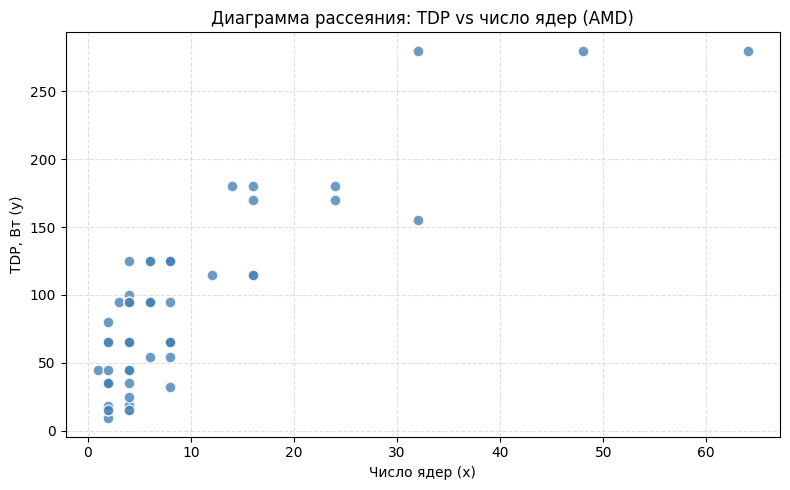

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='steelblue', edgecolors='white', s=60, alpha=0.8)
ax.set_xlabel('Число ядер (x)')
ax.set_ylabel('TDP, Вт (y)')
ax.set_title('Диаграмма рассеяния: TDP vs число ядер (AMD)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Гипотеза о характере связи**

По графику видно, что с ростом числа ядер TDP в целом растёт - связь положительная. При малом числе ядер (1-8) разброс очень большой: есть и 9 Вт и 125 Вт при одинаковом числе ядер, это скорее всего из-за того, что среди бюджетных низковольтных и десктопных процессоров большая разница в классе, при 16+ ядрах данные уже плотнее группируются в районе 115-280 Вт

Характер зависимости выглядит нелинейным - рост замедляется при малых x и ускоряется при больших, что напоминает степнную функцию
Линейная модель тоже разумна как базовый вариант, но скорее всего будет хуже отражать реальность на краях диапазона

Итого: ожидаем, что степенная или квадратичная модель покажет себя лучше линейной.

## 2. Построение трёх моделей

### 2.1 Линейная модель: y = a + b*x

In [3]:
# МНК 
xmean = np.mean(x)
ymean = np.mean(y)

Sxx = np.sum((x - xmean)**2)
Sxy = np.sum((x - xmean) * (y - ymean))

b1 = Sxy / Sxx          # коэф при x
b0 = ymean - b1 * xmean # свободный член

y_lin = b0 + b1 * x

print(f'theta_0 (a) = {b0:.4f}')
print(f'theta_1 (b) = {b1:.4f}')
print(f'Уравнение: y_hat = {b0:.2f} + {b1:.2f} * x')

theta_0 (a) = 46.9830
theta_1 (b) = 4.7481
Уравнение: y_hat = 46.98 + 4.75 * x


### 2.2 Квадратичная модель: y = a + b*x + c*x^2

In [4]:
# polyfit возвращает коэффициенты от старшей степени к меньшей
coeffs_q = np.polyfit(x, y, 2)
c2, c1, c0 = coeffs_q

y_quad = c0 + c1*x + c2*x**2

print(f'a = {c0:.4f}')
print(f'b = {c1:.4f}')
print(f'c = {c2:.4f}')
print(f'Уравнение: y_hat = {c0:.2f} + {c1:.2f}*x + ({c2:.4f})*x^2')

a = 29.7140
b = 8.2768
c = -0.0682
Уравнение: y_hat = 29.71 + 8.28*x + (-0.0682)*x^2


### 2.3 Степенная модель: y = a * x^b

Линеаризуем логарифмированием: ln(y) = ln(a) + b * ln(x)

Делаем замену: Y' = ln(y), X' = ln(x), тогда Y' = ln(a) + b * X' - обычная линейная регрессия, оцениваем её МНК, потом возвращаемся к исходным параметрам.

In [5]:
log_x = np.log(x)
log_y = np.log(y)

# полиномиальная подгонка в лог-пространстве
b_pow, ln_a = np.polyfit(log_x, log_y, 1)
a_pow = np.exp(ln_a)

y_pow = a_pow * x**b_pow

print(f'a = {a_pow:.4f}')
print(f'b = {b_pow:.4f}')
print(f'Уравнение: y_hat = {a_pow:.2f} * x^{b_pow:.4f}')

a = 22.2110
b = 0.6502
Уравнение: y_hat = 22.21 * x^0.6502


### Графики всех трёх моделей на фоне данных

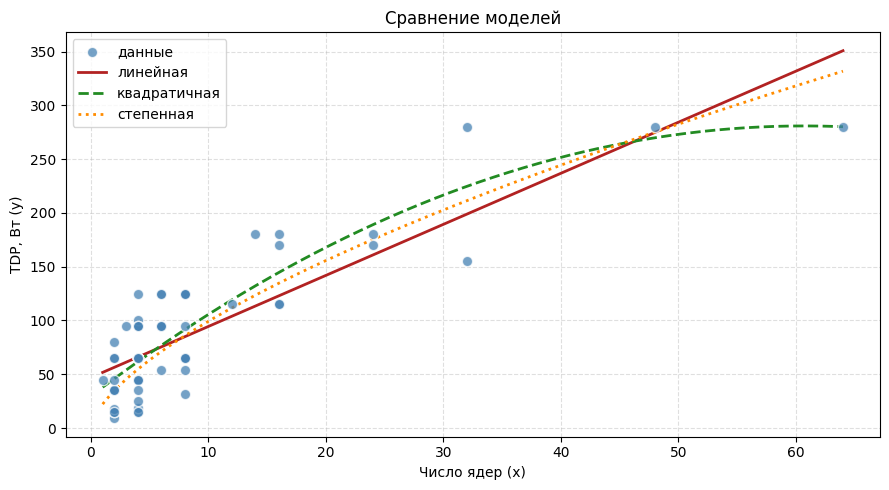

In [6]:
x_plot = np.linspace(x.min(), x.max(), 300)
y_lin_plot = b0 + b1 * x_plot
y_quad_plot = c0 + c1*x_plot + c2*x_plot**2
y_pow_plot = a_pow * x_plot**b_pow

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color='steelblue', edgecolors='white', s=55, alpha=0.75, zorder=3, label='данные')
ax.plot(x_plot, y_lin_plot, color='firebrick', lw=2, label='линейная')
ax.plot(x_plot, y_quad_plot, color='forestgreen', lw=2, linestyle='--', label='квадратичная')
ax.plot(x_plot, y_pow_plot, color='darkorange', lw=2, linestyle=':', label='степенная')

ax.set_xlabel('Число ядер (x)')
ax.set_ylabel('TDP, Вт (y)')
ax.set_title('Сравнение моделей')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Сравнение моделей

Считаем R^2, RMSE и среднюю ошибку аппроксимации (MAPE) для всех трёх

In [16]:
TSS = np.sum((y - ymean)**2)

def metrics(y_true, y_pred, name):
    rss = np.sum((y_true - y_pred)**2)
    r2 = 1 - rss / TSS
    rmse = np.sqrt(rss / len(y_true))
    mape = 100 / len(y_true) * np.sum(np.abs((y_true - y_pred) / y_true))
    print(f'{name}: R^2 = {r2:.4f},  RMSE = {rmse:.2f},  MAPE = {mape:.2f}%')
    return rss, r2, rmse, mape

rss_lin, r2_lin, rmse_lin, mape_lin = metrics(y, y_lin, 'Линейная')
rss_quad, r2_quad, rmse_quad, mape_quad = metrics(y, y_quad, 'Квадратичная')
rss_pow, r2_pow, rmse_pow, mape_pow = metrics(y, y_pow, 'Степенная')

Линейная: R^2 = 0.7079,  RMSE = 34.07,  MAPE = 65.59%
Квадратичная: R^2 = 0.7609,  RMSE = 30.82,  MAPE = 58.13%
Степенная: R^2 = 0.7362,  RMSE = 32.37,  MAPE = 50.66%


In [8]:
# сводная таблица
table = pd.DataFrame({
    'Модель': ['Линейная', 'Квадратичная', 'Степенная'],
    'R^2': [r2_lin, r2_quad, r2_pow],
    'RMSE': [rmse_lin, rmse_quad, rmse_pow],
    'MAPE, %': [mape_lin, mape_quad, mape_pow]
})
table = table.round(4)
print(table.to_string(index=False))

      Модель    R^2    RMSE  MAPE, %
    Линейная 0.7079 34.0671  65.5857
Квадратичная 0.7609 30.8222  58.1309
   Степенная 0.7362 32.3699  50.6625


### Графики остатков

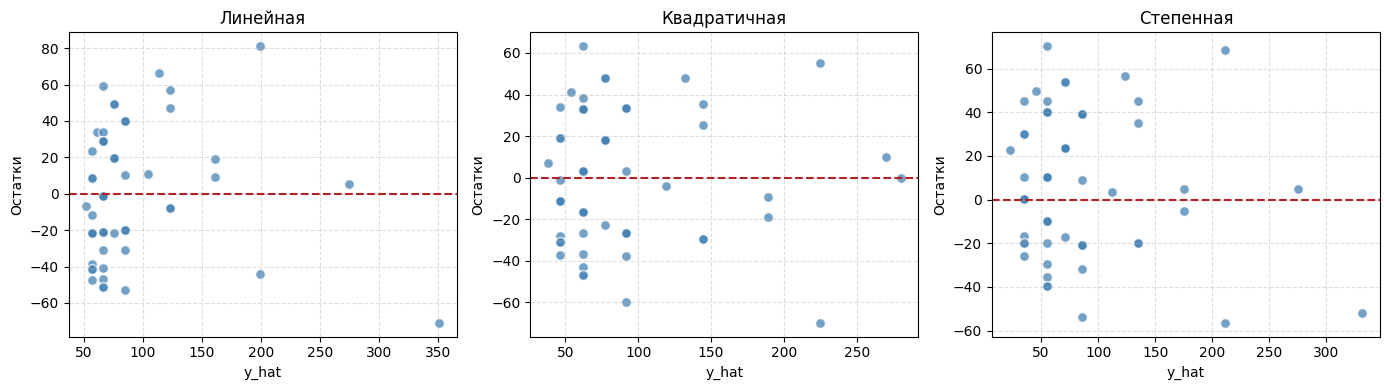

In [9]:
resid_lin = y - y_lin
resid_quad = y - y_quad
resid_pow = y - y_pow

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, resid, yhat, name in zip(
    axes,
    [resid_lin, resid_quad, resid_pow],
    [y_lin, y_quad, y_pow],
    ['Линейная', 'Квадратичная', 'Степенная']
):
    ax.scatter(yhat, resid, color='steelblue', edgecolors='white', s=50, alpha=0.75)
    ax.axhline(0, color='firebrick', lw=1.5, linestyle='--')
    ax.set_xlabel('y_hat')
    ax.set_ylabel('Остатки')
    ax.set_title(name)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Вывод по сравнению моделей**

Смотрим на числа из таблицы выше:

- Квадратичная модель даёт наибольший R^2 (~0.76) и наименьший RMSE
- Степенная модель показывает наилучшую MAPE (~50.7%), то есть относительные ошибки у неё меньше
- Линейная - самая слабая по всем метрикам

На графиках остатков у всех трёх моделей заметен неравномерной разброс ошибки: при малых предсказанных значениях остатки разбросаны сильнее. Это логично - при малом числе ядер TDP гуляет широко (бюджетные vs. высокопроизводительные чипы)

Квадратичная чуть лучше линейной по R^2 и RMSE, но коэффициент при x^2 очень маленький по абсолютной величине (-0.07), так что практически вся разница между ними минимальна. Степенная модель физически более интерпретируема для данной задачи - нет смысла ожидать, что TDP будет расти строго линейно с числом ядер. Поэтому как основную для прогноза выбираем **степенную** модель.


## 4. Подробный статистический анализ линейной модели

In [10]:
# остатки и RSS
e = y - y_lin
RSS = np.sum(e**2)
print(f'RSS = {RSS:.2f}')

# несмещённая оценка дисперсии
s2 = RSS / (n - 2)
s = np.sqrt(s2)
print(f's^2 = {s2:.4f}')
print(f's   = {s:.4f}')

RSS = 69634.03
s^2 = 1200.5868
s   = 34.6495


In [11]:
# стандартные ошибки коэффициентов
SE_b1 = s / np.sqrt(Sxx)
SE_b0 = s * np.sqrt(1/n + xmean**2 / Sxx)

print(f'SE(theta_1) = {SE_b1:.4f}')
print(f'SE(theta_0) = {SE_b0:.4f}')

SE(theta_1) = 0.4005
SE(theta_0) = 5.6950


In [12]:
# квантиль Стьюдента для 95% ДИ
t_crit = stats.t.ppf(0.975, df=n-2)
print(f't_{{1-alpha/2; n-2}} = t_{{0.975; {n-2}}} = {t_crit:.4f}')

# доверительные интервалы
ci_b1 = (b1 - t_crit * SE_b1, b1 + t_crit * SE_b1)
ci_b0 = (b0 - t_crit * SE_b0, b0 + t_crit * SE_b0)

print(f'95% ДИ для theta_1: [{ci_b1[0]:.4f}, {ci_b1[1]:.4f}]')
print(f'95% ДИ для theta_0: [{ci_b0[0]:.4f}, {ci_b0[1]:.4f}]')

t_{1-alpha/2; n-2} = t_{0.975; 58} = 2.0017
95% ДИ для theta_1: [3.9464, 5.5499]
95% ДИ для theta_0: [35.5832, 58.3829]


In [13]:
# проверка гипотезы H0: theta_1 = 0
t_obs = b1 / SE_b1
print(f't_набл = {t_obs:.4f}')
print(f't_крит = {t_crit:.4f}')
print(f'|t_набл| > t_крит: {abs(t_obs) > t_crit}')

p_value = 2 * (1 - stats.t.cdf(abs(t_obs), df=n-2))
print(f'p-value = {p_value:.2e}')

t_набл = 11.8545
t_крит = 2.0017
|t_набл| > t_крит: True
p-value = 0.00e+00


**Вывод о значимости линейной модели**

|t_набл| >> t_крит (11.85 >> 2.00), p-value практически равен нулю. Гипотеза H0: theta_1 = 0 отвергается на уровне значимости 0.05. Коэффициент при x статистически значим - линейная зависимость между числом ядер и TDP подтверждается

Доверительный интервал для theta_1 = [3.95, 5.55] - ноль не входит, что согласуется с отклонением H0

Интерпретация коэффициента: в среднем каждое дополнительное ядро добавляет примерно 4.75 Вт к TDP процессора

In [14]:
# таблица остатков
resid_df = pd.DataFrame({
    'x_i': x,
    'y_i': y,
    'y_hat_i': y_lin.round(2),
    'e_i': e.round(2)
})
print('Первые 10 наблюдений:')
print(resid_df.head(10).to_string(index=False))

Первые 10 наблюдений:
 x_i  y_i  y_hat_i    e_i
 1.0 45.0    51.73  -6.73
 2.0 65.0    56.48   8.52
 2.0  9.0    56.48 -47.48
 2.0 15.0    56.48 -41.48
 2.0 35.0    56.48 -21.48
 2.0 18.0    56.48 -38.48
 2.0 15.0    56.48 -41.48
 2.0 35.0    56.48 -21.48
 2.0 35.0    56.48 -21.48
 2.0 65.0    56.48   8.52


## 5. Прогноз при x* = 9.3280

In [15]:
xstar = 9.3280

yhat_lin = b0 + b1 * xstar
yhat_quad = c0 + c1 * xstar + c2 * xstar**2
yhat_pow = a_pow * xstar**b_pow

print(f'x* = {xstar}')
print(f'Прогноз (линейная):    {yhat_lin:.2f} Вт')
print(f'Прогноз (квадратичная): {yhat_quad:.2f} Вт')
print(f'Прогноз (степенная):   {yhat_pow:.2f} Вт')

x* = 9.328
Прогноз (линейная):    91.27 Вт
Прогноз (квадратичная): 100.99 Вт
Прогноз (степенная):   94.87 Вт


**Выбор модели для прогноза**

Как основную для прогноза выбираем **степенную модель**. Причины:

1. Степенная модель даёт наименьшую MAPE (~50.7%) - относительные ошибки меньше, чем у линейной
2. По форме кривой на графике степенная лучше описывает поведение при малом числе ядер (не уходит в слишком большие значения при x -> 0)
3. Модель y = a * x^b физически более осмысленна: рост TDP при добавлении ядер замедляется, что логично - производители оптимизируют энергопотребление при масштабировании

**Прогноз:** при x* = 9.3280 ядер степенная модель даёт TDP ≈ 94.87 Вт

Это примерно соответствует классу средних десктопных или серверных AMD-процессоров - вполне реалистичная оценка для ~9 ядер.

## 6. Итоговый вывод

В работе исследовался набор данных `openintro::cpu`, срез по процессорам AMD (n = 60). Изучалась зависимость теплопакета TDP (Вт) от числа ядер процессора.

По диаграмме рассеяния видна положительная связь - больше ядер, выше TDP. При этом разброс очень большой: среди двух- и четырёхъядерных процессоров TDP варьируется от 9 до 125 Вт, что объясняется разнообразием ценовых классов и серий AMD

Были построены три модели: линейная (R^2 = 0.708), квадратичная (R^2 = 0.761) и степенная (R^2 = 0.736). По совокупности метрик квадратичная даёт лучший R^2 и RMSE, но степенная показывает наименьшую MAPE (50.7% vs 58.1% у квадратичной) и лучше интерпретируется содержательно

Для линейной модели проведён полный статистический анализ: коэффициент наклона theta_1 = 4.748 статистически значим (t_набл = 11.85 >> t_крит = 2.00, p-value ~ 0), что подтверждает линейную зависимость между x и y на уровне 0.05

Прогноз при x* = 9.328 ядер по степенной модели составляет **94.87 Вт** - это реалистичное значение для AMD-процессора с ~9 ядрами

Итог: число ядер хорошо объясняет TDP (R^2 около 0.74-0.76), но остаётся значительный необъяснённый разброс - вероятно, другие факторы (тактовая частота, серия, техпроцесс, мобильный vs. десктопная темка и тд) также влияют на энергопотребление.